Sample code to emulate a forward run using pre-computed footprints

In [1]:
from omegaconf import OmegaConf
from pandas import date_range, DataFrame
import xarray as xr
from pathlib import Path
from tm5.fitic import read_obs_table


# TM5 run has been prepared without any emissions (just forward propagation of the initial condition)
conf = OmegaConf.load('background_20260331_gns1x1.yaml')
conf.host = conf.cosmos

# Load the observations table
obs_table = read_obs_table(conf.observations.file).set_index('obsid')
tracers = set(obs_table.tracer)

# Accumulators:
date, region, obs, dmix = [], [], [], []

for day in date_range(conf.run.start, conf.run.end, freq='1d'):
    for reg in conf.run.regions:
        adjfile = day.strftime(f'{conf.run.paths.output}/adjemis/adjemis.{reg}.%Y%m%d.nc')
        
        # Adjoint files are written only if needed, so it may not exist for a given day/region
        if not Path(adjfile).exists():
            continue
        
        # I don't know which key should code for that exact path ... for now I guessed ...
        adj = xr.open_dataset(day.strftime(f'{conf.run.paths.output}/adjemis/adjemis.{reg}.%Y%m%d.nc'))
        
        ilons = adj.ilon.values
        ilats = adj.ilat.values
        sensi = adj['values'].values
        itrac = adj.itrac.values
            
        # Read the emissions. For now, I'm hardcoding this to CH4 ...
        em = xr.open_dataset(day.strftime(f'{conf.emissions.CH4.prefix}.CH4.{reg}.%Y%m%d.nc'))
        emtot = em.to_array().sum('variable').values
        
        for itr in set(itrac):
            date.append(day)
            region.append(reg)
            obs.append(adj.tracer.values[itr].strip().decode())
            
            subset = itrac == itr
            dmix.append((emtot[ilats[subset], ilons[subset]] * sensi[subset]).sum())
            
# Store everything in a common dataframe. Each row contains the contribution of one date and region to one specific obs
fwd = DataFrame.from_dict({'obs': obs, 'region': region, 'date': date, 'mix': dmix})

# Do some plots with what we just computed:

## 1. Contribution of the emissions each date to each observation:

array([<Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='d

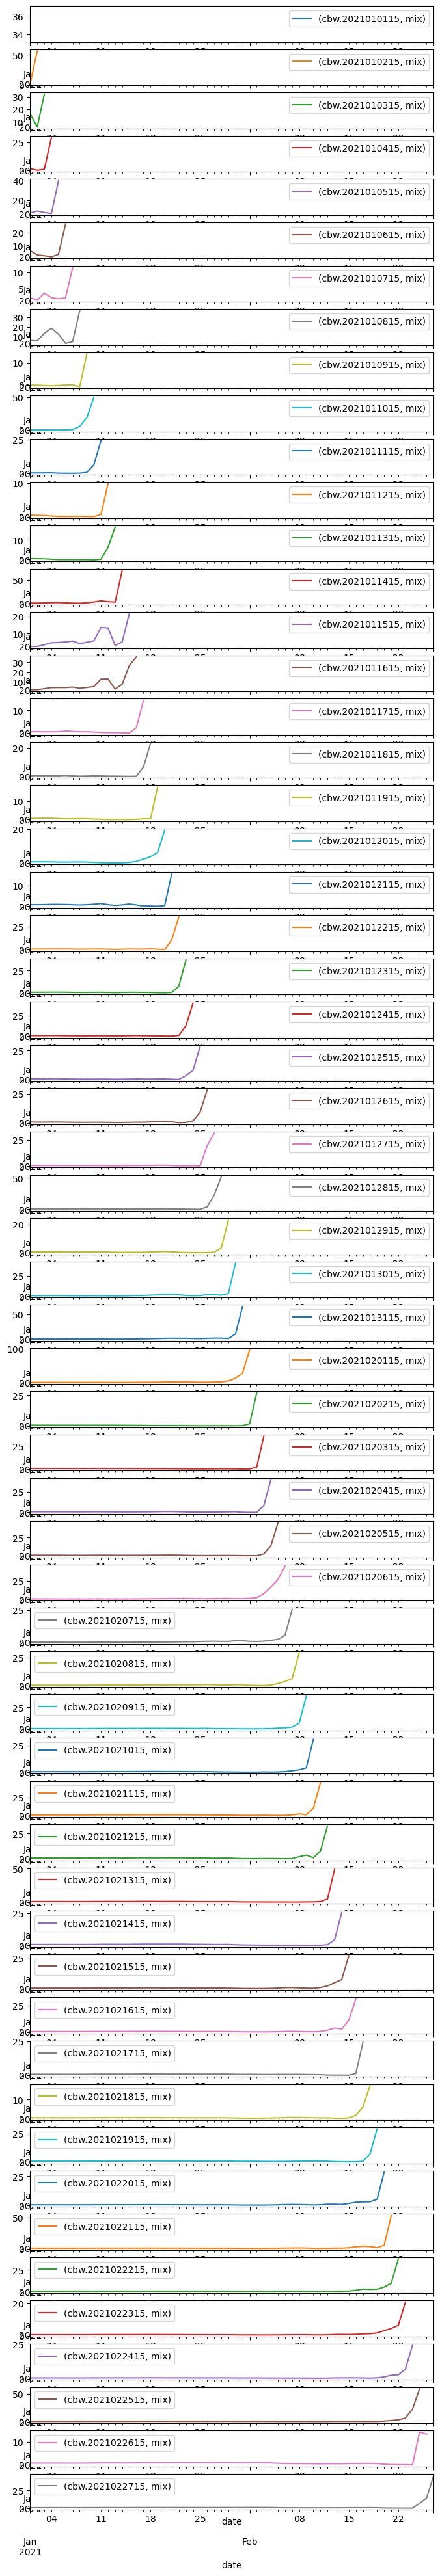

In [12]:
fwd.groupby(['obs', 'date']).sum(numeric_only=True).reset_index().plot(by='obs', x='date', figsize=(8, 50))

# 2. Contribution of each region to each observations:

array([<Axes: xlabel='region'>, <Axes: xlabel='region'>,
       <Axes: xlabel='region'>, <Axes: xlabel='region'>,
       <Axes: xlabel='region'>, <Axes: xlabel='region'>,
       <Axes: xlabel='region'>, <Axes: xlabel='region'>,
       <Axes: xlabel='region'>, <Axes: xlabel='region'>,
       <Axes: xlabel='region'>, <Axes: xlabel='region'>,
       <Axes: xlabel='region'>, <Axes: xlabel='region'>,
       <Axes: xlabel='region'>, <Axes: xlabel='region'>,
       <Axes: xlabel='region'>, <Axes: xlabel='region'>,
       <Axes: xlabel='region'>, <Axes: xlabel='region'>,
       <Axes: xlabel='region'>, <Axes: xlabel='region'>,
       <Axes: xlabel='region'>, <Axes: xlabel='region'>,
       <Axes: xlabel='region'>, <Axes: xlabel='region'>,
       <Axes: xlabel='region'>, <Axes: xlabel='region'>,
       <Axes: xlabel='region'>, <Axes: xlabel='region'>,
       <Axes: xlabel='region'>, <Axes: xlabel='region'>,
       <Axes: xlabel='region'>, <Axes: xlabel='region'>,
       <Axes: xlabel='region'>,

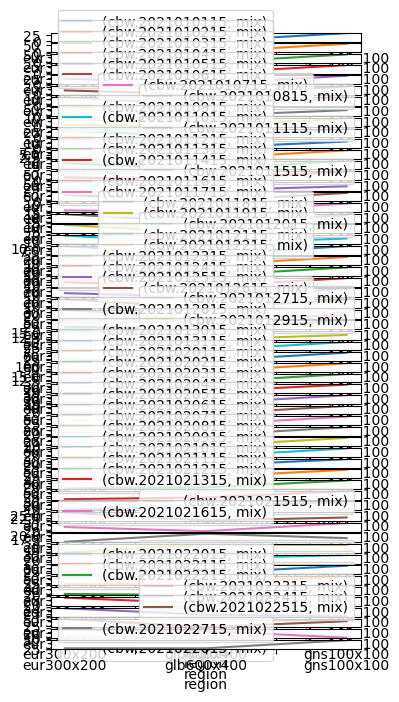

In [13]:
fwd.groupby(['obs', 'region']).sum(numeric_only=True).reset_index().plot(by='obs', x='region', figsize=(4, 8))

# 3. Timeseries (without initial condition ...)

For this, we need to recombine with the original `obs_table` dataframe.

Right now it's a bit silly because the obs are from different sites ...

In [59]:
import hvplot.xarray

bg = xr.open_dataset(Path(conf.run.paths.output)/'point/point_output.nc4', group='gns100x100/CH4').mixing_ratio.values
ref = xr.open_dataset('/lunarc/nobackup/projects/ghg_inv/guillaume/iLab/TM5/output/tests_adjoint_gns100x100/point/point_output.nc4', group='gns100x100/CH4').mixing_ratio.values
ym = fwd.groupby('obs').sum(numeric_only=True)
# ym.loc[:, 'mix'] += ym.iniconc.values
obs_table.loc[ym.index.values, 'dmix'] = ym.mix.values
obs_table.loc[ym.index.values, 'iniconc'] = bg
obs_table.loc[ym.index.values, 'mix'] = ym.mix.values + bg
obs_table.loc[ym.index.values, 'ref'] = ref
(
    obs_table.hvplot(x='time', y='mix', label='mix-footprints').opts(show_legend=True, line_width=6, alpha=.5, show_grid=True) * 
    obs_table.hvplot(x='time', y='iniconc', label='iniconc').opts(show_legend=True) * 
    obs_table.hvplot(x='time', y='ref', label='mix-model').opts(show_legend=True)
).opts(width=1000, height=400, title='Cabauw')
# obs_table.hvplot(x='time', y=['mix', 'iniconc', 'ref'], grid=True)


:Overlay
   .Curve.Mix_hyphen_minus_footprints :Curve   [time]   (mix)
   .Curve.Iniconc                     :Curve   [time]   (iniconc)
   .Curve.Mix_hyphen_minus_model      :Curve   [time]   (ref)

# Plot the footprint themselves

In [69]:
from numpy import zeros, tile
from matplotlib.pyplot import subplots, colorbar
from pathlib import Path
from pandas import Timestamp, concat
from netCDF4 import Dataset
from tm5.gridtools import TM5Grids


outpath = Path(conf.run.paths.output)/'adjemis'
regions = conf.run.regions
obsids = list(obs_table.index)
start = Timestamp(conf.run.start)
end = Timestamp(conf.run.end)

footprints = {'ilat':[], 'ilon':[], 'itime':[], 'value':[], 'region':[], 'itrac':[]}
for itrac, tracer in enumerate(tracers):
    for iday, day in enumerate(date_range(start, end, freq='d')):
        for ireg, region in enumerate(regions):
            fname = outpath / day.strftime(f'adjemis.{region}.%Y%m%d.nc')
            if not fname.exists():
                continue
            with Dataset(fname, 'r') as ds:
                ilat = ds['ilat'][:].data
                ilon = ds['ilon'][:].data
                itrac = ds['itrac'][:].data
                values = ds['values'][:].data
            ndat = len(ilat)
            
            footprints['ilat'].extend(ilat)
            footprints['ilon'].extend(ilon)
            footprints['itime'].extend([iday] * ndat)
            footprints['value'].extend(values)
            footprints['itrac'].extend(itrac)
            footprints['region'].extend([region] * ndat)
footprints = DataFrame.from_dict(footprints)


# Correct the halos:
r2 = footprints[footprints.region == 'eur300x200']
footprints.loc[footprints.region == 'eur300x200', 'ilon'] = r2.ilon.values - 2
footprints.loc[footprints.region == 'eur300x200', 'ilat'] = r2.ilat.values - 2
r3 = footprints[footprints.region == 'gns100x100']
footprints.loc[footprints.region == 'gns100x100', 'ilon'] = r3.ilon.values - 3
footprints.loc[footprints.region == 'gns100x100', 'ilat'] = r3.ilat.values - 2

# ------------------
# Reproject the eur3x2 data on a 1x1 grid
fpreg = footprints[footprints.region == 'eur300x200']
grid0 = TM5Grids.from_corners(west=-36+6, east=54-6, south=22+4, north=74-4, dlon=3, dlat=2)
grid1 = TM5Grids.from_corners(west=-36+6, east=54-6, south=22+4, north=74-4, dlon=1, dlat=1)

# Duplicate the points
rlon, rlat = 3, 2
ilat = tile(fpreg.ilat.values * rlat, (rlat, rlon, 1))
ilon = tile(fpreg.ilon.values * rlon, (rlat, rlon, 1))
values = tile(fpreg.value.values, (rlat, rlon, 1)).reshape(-1)
itime = tile(fpreg.itime.values, (rlat, rlon, 1)).reshape(-1)
itrac = tile(fpreg.itrac.values, (rlat, rlon, 1)).reshape(-1)

# Adjust the indices
for jj in range(rlat):
    ilat[jj, :, :] += jj
for ii in range(rlon):
    ilon[:, ii, :] += ii
    
# Re-create a DataFrame:
df_eur = DataFrame.from_dict(dict(ilat=ilat.reshape(-1), ilon=ilon.reshape(-1), value=values, itime=itime, itrac=itrac))
df_eur.loc[:, 'region'] = 'eur300x200'

# Adjust the indices to those of a glb1x1 grid:
df_eur.loc[:, 'ilat'] += grid1.south + 90
df_eur.loc[:, 'ilon'] += grid1.west + 180

# ------------------
# Reproject the glb6x4 grid on glo1x1

fpreg = footprints[footprints.region == 'glb600x400']
grid0 = TM5Grids.from_corners(west=-180, east=180, south=-90, north=90, dlon=6, dlat=4)
grid1 = TM5Grids.from_corners(west=-180, east=180, south=-90, north=90, dlon=1, dlat=1)

rlon, rlat = 6, 4
ilat = tile(fpreg.ilat.values * rlat, (rlat, rlon, 1))
ilon = tile(fpreg.ilon.values * rlon, (rlat, rlon, 1))
values = tile(fpreg.value.values, (rlat, rlon, 1)).reshape(-1)
itime = tile(fpreg.itime.values, (rlat, rlon, 1)).reshape(-1)
itrac = tile(fpreg.itrac.values, (rlat, rlon, 1)).reshape(-1)

for jj in range(rlat):
    ilat[jj, :, :] += jj
for ii in range(rlon):
    ilon[:, ii, :] += ii
    
df_glb = DataFrame.from_dict(dict(ilat=ilat.reshape(-1), ilon=ilon.reshape(-1), value=values, itime=itime, itrac=itrac))
df_glb.loc[:, 'region'] = 'eur600x400'

# ---------------------
# Finally reproject gns1x1 on glo1x1
df_gns = footprints[footprints.region == 'gns100x100']
grid0 = TM5Grids.from_corners(west=0+3, east=18-3, south=42+2, north=58-2, dlon=1, dlat=1)
df_gns.loc[:, 'ilat'] += grid0.south + 90
df_gns.loc[:, 'ilon'] += grid0.west + 180

# ----------------------
# Concatenate all 3 dataframes

df_tot = concat([df_eur, df_glb, df_gns])

(33.0, 73.0)

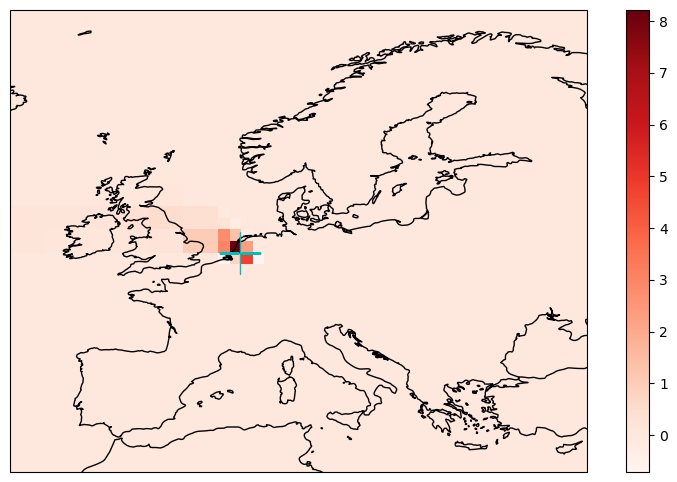

In [81]:
from cartopy import crs
from matplotlib.pyplot import colorbar

# Store all footprints in a single array 
fp = zeros(((end - start).days, 180, 360, len(obsids)))
fp[df_tot.itime, df_tot.ilat, df_tot.ilon, df_tot.itrac] = df_tot.value

# What to plot?
# fp is a (nt, nlat, nlon, nobs) array:
# fp.sum(0).sum(-1) => Plot the total footprint of all obs
# fp[..., i].sum(0) => Plot the footprint i, aggregated in time
# fp[i, ...].sum(-1) => Plot the total footprint of all obs, at model timestep i
fpplot = fp.sum(0).sum(-1)
fpplot = fp[..., -1].sum(0)

f, ax = subplots(1, 1, figsize=(10, 6), subplot_kw=dict(projection=crs.PlateCarree()))
ax.set_global()
colorbar(ax.imshow(fpplot, origin='lower', extent=(-180, 180, -90, 90), cmap='Reds'))
ax.coastlines()


# Add the obs coordinates
coords = obs_table[['lat', 'lon']].drop_duplicates()
ax.plot(coords.lon, coords.lat, 'c+', ms=30, alpha=1)

# Restrict to a smaller domain:
ax.set_xlim(-15, 35)
ax.set_ylim(33, 73)